# FHN Control

## FHN Model

The FitzHugh-Nagumo model is described by the two coupled differential equations

$$ \begin{align}
\dot{x_1} &= h_1(x_1, x_2) = -\alpha x_1^3 + \beta x_1^2 + \gamma x_1 - x_2 + I_{ext,1}\\
\dot{x_2} &= h_2(x_1, x_2) = \frac{1}{\tau} (x_1 - \delta - \epsilon x_2) = \frac{1}{\tau} (x_1 - \epsilon x_2) + I_{ext,2},
\end{align}$$

or $\dot{\mathbf{x}} = \mathbf{h}(\mathbf{x})$. We impose the boundary condition $\mathbf{x}(t=0) = \mathbf{x}_0$.

We chose the parameters as follows:

$$ \begin{align}
\dot{x_1} &= -3 x_1^3 + 4 x_1^2 - 1.5 x_1 - x_2 + I_{ext} \\
\dot{x_2} &= \frac{1}{20} (x_1 - 8 x_2),
\end{align}$$

In [300]:
# change to the root directory of the project
import os
if os.getcwd().split("/")[-1] == "examples":
    os.chdir('..')
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Let's import the fhn model
from neurolib.models.fhn import FHNModel
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2  

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [301]:
# Set plot and print options
plt.rcParams['axes.grid'] = True
# a nice color map
plt.rcParams['image.cmap'] = 'plasma'
plt.rcParams['font.size'] = 8
plt.rcParams['legend.fontsize'] = 'large'
plt.rcParams['figure.titlesize'] = 'medium'
plt.rcParams['lines.linewidth'] = 0.8
np.set_printoptions(precision=3)

In [349]:
# define model parameters and external input such that we find bistability
# in the model above, no external input to x_2 is included

fhn = FHNModel()

epsilon = 8.0
external_input = [0.2, 0.0]

fhn.params['x_ext'] = np.array([external_input[0]])
fhn.params['y_ext'] = np.array([external_input[1]])
fhn.params['epsilon'] = epsilon

### State space

Depending on $I_{ext}$, there can be one or three fixed points. In the case of three fixed points, one in unstable. We find bistability for an input current $I_{ext} = 0.2$.

Fixed points:  [[0.235 0.029]
 [0.414 0.052]
 [0.684 0.085]]


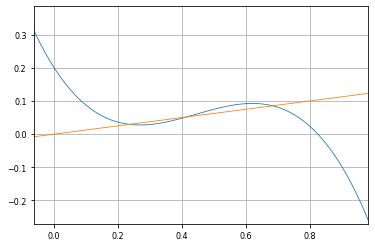

In [4]:
# the intersection of the nullclines is at
# the turning point is at beta/(3 alpha), gradient at turning point is beta^2/(3 alpha) + gamma
# for parameter choice 1/epsilon >  gradient = 59/18, there is only one fixed point for any choice of I_ext
def x1_nullcline(x_):
    return -fhn.params['alpha']*x_**3 + fhn.params['beta']*x_**2 +fhn.params['gamma']*x_ + fhn.params['x_ext']

def x2_nullcline(x_):
    return (x_ + fhn.params['y_ext']*fhn.params['tau'])/fhn.params['epsilon']

def fp_func(x_):
    return x2_nullcline(x_) - x1_nullcline(x_)

low_lim = -2.
up_lim = 2.
x = np.arange(low_lim,up_lim,0.01)

ic_bistability = [0.2, 0.4, 0.6]

# fixed points for default parameter choice
fixed_points_x = fsolve(fp_func, ic_bistability)
fixed_points = np.zeros([len(fixed_points_x), 2])
for i in range(len(fixed_points_x)):
    fixed_points[i,:] = [fixed_points_x[i], x1_nullcline(fixed_points_x[i])[0]]
print("Fixed points: ", np.around(fixed_points,3))

plt.plot(x,x1_nullcline(x))
plt.plot(x,x2_nullcline(x))
plt.xlim(fixed_points_x[0]-0.3, fixed_points_x[-1]+0.3)
plt.ylim(min(fixed_points[:,1])-0.3, max(fixed_points[:,1])+0.3)
plt.show()

### Fixed points

In this bistable regime, we want to investigate control mechanisms to drive the system from one stable fixed point to the other. For $I_{ext} = 0.2$, the two stable fixed points are located at $\mathbf{x}_{low} = (0.235, 0.029)$ and $\mathbf{x}_{high} = (0.684, 0.085)$.

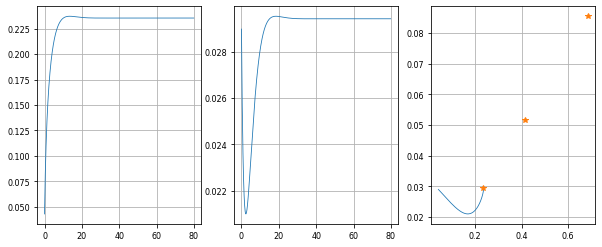

In [350]:
# starting close to the three fixed points, we see that two of them are stable
initial_state = [[0.2, 0.0], [0.4, 0.05], [0.7, 0.1]]
fp = 1 # 0,1,2 for three fixed points initial conditions

#set duration of simulation
duration = 80 # in ms
fhn.params['duration'] = duration
#fhn.params['dt'] = 0.1
fhn.run()

t = np.arange(0, fhn.params['duration'], fhn.params['dt'])

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].plot(t, fhn.x[0,:])
ax[1].plot(t, fhn.y[0,:])
ax[2].plot(fhn.x[0,:], fhn.y[0,:])
ax[2].plot(fixed_points[:,0], fixed_points[:,1], '*')
plt.show()



### Control mechanism

Control is expressed as

$$ \begin{align}c_1 &= c_1(t)\\
c_2 &= c_2(t),
\end{align}$$

and impacts the FHN neuron as an eternal input,

$$ \begin{align}
\dot{\mathbf{x}} = \mathbf{h}(\mathbf{x}) + \mathbf{c}(t).
\end{align}$$

In [347]:
# step function as control function
def step_control(t_, input_max_, start_, stop_):
    if (t_ >= start_*fhn.params['duration'] and t_ <= stop_*fhn.params['duration']):
        return input_max_
    return [0., 0.]

# half sine for first half of simulation time as control function
def sin_control(t_, input_max):
    if (t_ < fhn.params['duration']/2):
        x1 = input_max * np.sin(2.*np.pi*t_/fhn.params['duration'])
        return [x1, 0.]
    return [0., 0.]

# fixed-point activity as control function
def fixed_point_control(t_, i):
    if (t_ < fhn.params['duration']/2):
        return [fixed_points[i,0] - fhn.params['x_ext'], fixed_points[i,1] - fhn.params['y_ext']]
    else:
        return [0., 0.]
    

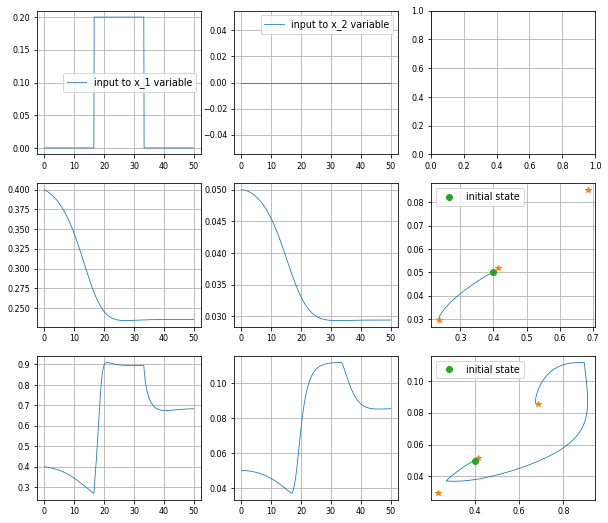

In [7]:
# Playing around with some control functions and see how they impact the system's time evolution
I_max = [0.2, 0.]

# prepare control input
control = fhn.getZeroControl()

for i in range(len(fhn.t)):
    #control[0, :, i] = fixed_point_control(fhn.t[i], 0)
    control[0, :, i] = step_control(fhn.t[i], I_max, 0.2, 0.5)  

# no control
fhn.run()

fig, ax = plt.subplots(3, 3, figsize=(10, 9))

ax[0,0].plot(fhn.t, control[0,0,:], label="input to x_1 variable")
ax[0,0].legend()
ax[0,1].plot(fhn.t, control[0,1,:], label="input to x_2 variable")
ax[0,1].legend()

ax[1,0].plot(fhn.t, fhn.x[0,:])
ax[1,1].plot(fhn.t, fhn.y[0,:])
ax[1,2].plot(fhn.x[0,:], fhn.y[0,:])
ax[1,2].plot(fixed_points[:,0], fixed_points[:,1], '*')
ax[1,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', label="initial state")
ax[1,2].legend()

fhn.run(control=control)

ax[2,0].plot(fhn.t, fhn.x[0,:])
ax[2,1].plot(fhn.t, fhn.y[0,:])
ax[2,2].plot(fhn.x[0,:], fhn.y[0,:])
ax[2,2].plot(fixed_points[:,0], fixed_points[:,1], '*')
ax[2,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', label="initial state")
ax[2,2].legend()
plt.show()

### Bistability: Switch from low state to high state

How to get from the low state to the high state most efficiently? The control is optimal, if it minimizes the cost functional $F$. For now, $F$ only penalizes the precision, that ist, the deviation from the stationary target state,

$$ \begin{align}
F(\mathbf{x}) = \int_0^T \underbrace{| \mathbf{x}(t) - \mathbf{x}_T|}_{= f(\mathbf{x}(\mathbf{c}), \mathbf{c})} dt.
\end{align}$$

We want to minimize $F(\mathbf{x})$ with $\mathbf{x}_T = \mathbf{x}_{high}$ under the constraints given by the time development $\dot{\mathbf{x}} = \mathbf{h}(\mathbf{x}) + \mathbf{c}(t)$, and the initial condition $\mathbf{x}_0 \approx \mathbf{x}_{low}$.

Hence, the optimal control $\mathbf{c}^*$ is given by

$$ \begin{align}
\mathbf{c}^* = arg\,min_\mathbf{c} F(\mathbf{x}(\mathbf{c})).
\end{align}$$

The optimal solution satisfies

$$ \begin{align}
\nabla_c F(\mathbf{x}({\mathbf{c}}), \mathbf{c})\big\vert_{\mathbf{c} = \mathbf{c}^*} = \int_0^T \nabla_c f(\mathbf{x}(\mathbf{c}), \mathbf{c})\big\vert_{\mathbf{c}= \mathbf{c}^*} = 0.
\end{align} $$

An even stronger condition is

$$ \begin{align}
\nabla_c f(\mathbf{x}(\mathbf{c}), \mathbf{c})\big\vert_{\mathbf{c}= \mathbf{c}^*} = 0.
\end{align} $$

In [304]:
# cost function
def f_cost(state_, target_state_):
    # state_: [N,dim_Model,t] dimensional array containing all nodes, state variables at all times
    # target_state: [N, dim_Model, t] dimensional array containing target state for all nodes, all variables (time-independent) at all times
    # return cost: [t] dimensional array containing cost for all times
    cost =  np.zeros((state_.shape[2]))
    for ind_node in range(state_.shape[0]):
        for ind_var in range(state_.shape[1]):
            for ind_time in range(state_.shape[2]):
                cost[ind_time] += np.abs(state_[ind_node, ind_var, ind_time] - target_state_[ind_node, ind_var, ind_time])
    return cost

# integrated cost
def f_int(cost_):
    # cost_: [t] dimensional array containing cost for all times
    # return cost_int: integrated (total) cost
    cost_int = 0.
    for ind_time in range(len(cost_)):
        cost_int += cost_[ind_time]*fhn.params['dt']
    return cost_int

In [305]:
# plot uncontrolled dynamics, controlled dynamics
def plot_control(target_, control_, cost_):
    
    # no control
    fhn.run()

    fig, ax = plt.subplots(3, 3, figsize=(18, 12))

    ax[0,0].plot(fhn.t, fhn.x[0,:], label="state x_1")
    ax[0,0].plot(fhn.t, target_[0,0,:], label="target state")
    ax[0,0].legend()
    ax[0,1].plot(fhn.t, fhn.y[0,:], label="state x_2")
    ax[0,1].plot(fhn.t, target_[0,1,:], label="target state")
    ax[0,1].legend()
    ax[0,2].plot(fhn.x[0,:], fhn.y[0,:])
    ax[0,2].plot(target_[0,0,:], target_[0,1,:], label="target state")
    ax[0,2].plot(target_[0,0,-1], target_[0,1,-1], '*', linewidth = 1, label="final target state")
    ax[0,2].plot(fhn.x[0,0], fhn.y[0,0], 'o', label="initial state")
    ax[0,2].legend()
    
    ax[1,0].plot(fhn.t, control_[0,0,:], label="input to x_1 variable")
    ax[1,0].legend()
    ax[1,1].plot(fhn.t, control_[0,1,:], label="input to x_2 variable")
    ax[1,1].legend()
    ax[1,2].plot(fhn.t, cost_, label="cost")
    ax[1,2].legend()

    fhn.run(control=control_)

    ax[2,0].plot(fhn.t, fhn.x[0,:], label="state x_1")
    ax[2,0].plot(fhn.t, target_[0,0,:], label="target state")
    ax[2,0].legend()
    ax[2,1].plot(fhn.t, fhn.y[0,:], label="state x_2")
    ax[2,1].plot(fhn.t, target_[0,1,:], label="target state")
    ax[2,1].legend()
    ax[2,2].plot(fhn.x[0,:], fhn.y[0,:])
    ax[2,2].plot(target_[0,0,:], target_[0,1,:], label="target state")
    ax[2,2].plot(target_[0,0,-1], target_[0,1,-1], '*', label="final target state")
    ax[2,2].plot(fhn.x[0,0], fhn.y[0,0], '*', label="initial state")
    ax[2,2].legend()
    
    plt.show()

In [321]:
# Gradient of the cost function with respect to the control
def gf_dc(control_, cost_, step_size_, target_, inst_tolerance_):
    
    ####### inputs:
    # control_: [N,dim_Model,t] dimensional array containing control for N nodes, dim_Model state variables for all times t
    # cost_: function that returns the [t] dimensional cost
    # step_size_: difference between control inputs at specific time
    # target_: [N,dim_Model,t] dimensional array containing target state
    ####### return:
    # grad: [N,dim_Model,t] dimensional array containing gradient for all times wrt control
    
    grad = np.zeros((control_.shape))
    delta_c = np.zeros((control_.shape))
    
    state0 = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
    fhn.run(control=control_)
    state0[:,0,:] = fhn.x[:,:]
    state0[:,1,:] = fhn.y[:,:]
    cost0 = cost_(state0, target_)
    
    control1 = control_.copy()
    state1 = state0

    for ind_node in range(control_.shape[0]):
        for ind_var in range(control_.shape[1]):
            # save for previous time steps
            for ind_time in range(control_.shape[2]):
                control1[ind_node, ind_var, ind_time] += step_size_
                fhn.run(control=control1)
                state1[:,0,:] = fhn.x[:,:]
                state1[:,1,:] = fhn.y[:,:]
                cost1 = cost_(state1, target_)
                control1[ind_node, ind_var, ind_time] -= step_size_ 
                
                grad[ind_node, ind_var, ind_time] = (cost1[ind_time] - cost0[ind_time])/step_size_
                if (np.abs(grad[ind_node, ind_var, ind_time]) < inst_tolerance_):
                    print('instantaneous zero reached')
                    break
                delta_c[ind_node, ind_var, ind_time] = - grad[ind_node, ind_var, ind_time] * step_size_
    
    return grad, delta_c
  

In [322]:
# control optimization

def opt_control(control_, cost_func_, step_size_, target_, tolerance_, inst_tolerance_, max_iteration_):
    ####### inputs:
    # control_: [N,dim_Model,t] dimensional array containing control for N nodes, dim_Model state variables for all times t
    # cost_func_: function that returns the [t] dimensional cost
    # step_size_: difference between control inputs at specific time
    # target_: [N,dim_Model,t] dimensional array containing target state
    # tolerance_: total integrated cost such that control is "optimal"
    # max_iteration: maximum number of iterations
    
    ####### return:
    # opt_control_: [N,dim_Model,t] dimensional array containing optimal control
    # best_control_: [N,dim_Model,t] dimensional array containing best guess
    
    state_ = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
    opt_control_ = fhn.getZeroControl()
    best_control_ = control_.copy()
    step_ = step_size_
    
    for i in range(max_iteration_):
        fhn.run(control = best_control_)

        state_[:,0,:] = fhn.x[:,:]
        state_[:,1,:] = fhn.y[:,:]
        cost_ = cost_func_(state_, target_)
        total_cost_ = f_int(cost_)
        print('RUN ', i, ', total integrated cost: ', total_cost_)
        if (total_cost_ < tolerance_):
            print('Optimal solution reached after ', i, ' iterations.')
            opt_control_ = best_control_
            break

        grad, delta_c = gf_dc(best_control_, f_cost, step_, target_, inst_tolerance_)
        #print('best control delta: ', delta_c)
        best_control_ += delta_c
        step_ *= 2./3.
        
    return opt_control_, best_control_

In [330]:
tolerance = 1e-2
inst_tolerance = 1e-6
step_size = 0.01

target_state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
start_fixed_point = 1 # lower (0), unstable (1) or upper (2)
target_fixed_point = 2 # lower (0), unstable (1) or upper (2)
fhn.params['xs_init']= np.array([[initial_state[start_fixed_point][0]]])
fhn.params['ys_init']= np.array([[initial_state[start_fixed_point][1]]])
target_state[:,0,:] = fixed_points[target_fixed_point,0]
target_state[:,1,:] = fixed_points[target_fixed_point,1]

control0 = fhn.getZeroControl()
max_iteration = 50

opt, best = opt_control(control0, f_cost, step_size, target_state, tolerance, inst_tolerance, max_iteration)

#print('optimal solution: ', opt)
#print('best solution: ', best)
state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
fhn.run(control = best)

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

RUN  0 , total integrated cost:  38.06920899717948
RUN  1 , total integrated cost:  38.55650552409714
RUN  2 , total integrated cost:  38.94695870359736
RUN  3 , total integrated cost:  39.27296323518571
RUN  4 , total integrated cost:  39.55183560634061
RUN  5 , total integrated cost:  39.79415865011919
RUN  6 , total integrated cost:  40.00698855952068
RUN  7 , total integrated cost:  40.195325826713216
RUN  8 , total integrated cost:  40.36287692957551
RUN  9 , total integrated cost:  40.5124853514449
RUN  10 , total integrated cost:  40.64639258462505
RUN  11 , total integrated cost:  40.766404849928364
RUN  12 , total integrated cost:  40.87400428416111
RUN  13 , total integrated cost:  40.970425774228424
RUN  14 , total integrated cost:  41.05671165534706
RUN  15 , total integrated cost:  41.13375164710578
RUN  16 , total integrated cost:  41.202312651565364
RUN  17 , total integrated cost:  41.26306141030046
RUN  18 , total integrated cost:  41.305500216052614
RUN  19 , total in

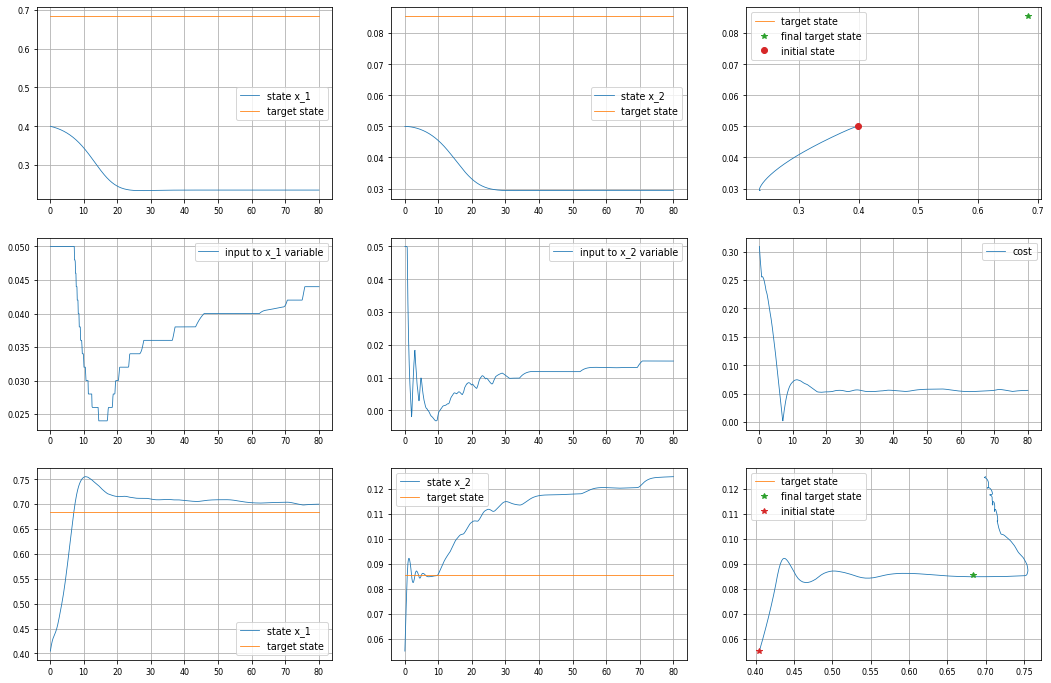

In [332]:
plot_control(target_state, best, f_cost(state, target_state))

In [362]:
# start with step function as control function

control0 = fhn.getZeroControl()
I_max = [0.05, 0.005]
for i in range(len(fhn.t)):
    control0[0, :, i] = step_control(fhn.t[i], I_max, 0.0, 0.05)
    
tolerance = 1e-2
inst_tolerance = 1e-6
step_size = 0.01
max_iteration = 20

target_state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
start_fixed_point = 1 # lower (0), unstable (1) or upper (2)
target_fixed_point = 2 # lower (0), unstable (1) or upper (2)
fhn.params['xs_init']= np.array([[initial_state[start_fixed_point][0]]])
fhn.params['ys_init']= np.array([[initial_state[start_fixed_point][1]]])
target_state[:,0,:] = fixed_points[target_fixed_point,0]
target_state[:,1,:] = fixed_points[target_fixed_point,1]

opt, best = opt_control(control0, f_cost, step_size, target_state, tolerance, inst_tolerance, max_iteration)

state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
fhn.run(control = best)

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

RUN  0 , total integrated cost:  0.8285547932240372
RUN  1 , total integrated cost:  1.2079550667928554
RUN  2 , total integrated cost:  1.2113562813614784
RUN  3 , total integrated cost:  1.169773583962448
RUN  4 , total integrated cost:  1.0844331884383958
RUN  5 , total integrated cost:  1.1098979655118657
RUN  6 , total integrated cost:  1.1088381129766884
RUN  7 , total integrated cost:  1.080770103558187
RUN  8 , total integrated cost:  1.0718996545124957
RUN  9 , total integrated cost:  1.0441542447200562
RUN  10 , total integrated cost:  1.0519876593889967
RUN  11 , total integrated cost:  1.0215262583652684
RUN  12 , total integrated cost:  1.024927252089155
RUN  13 , total integrated cost:  0.994558816986173
RUN  14 , total integrated cost:  1.0047037234654457
RUN  15 , total integrated cost:  0.9783435750598362
RUN  16 , total integrated cost:  0.9833868467984809
RUN  17 , total integrated cost:  0.9508573710792
RUN  18 , total integrated cost:  0.9430659049969715
RUN  19 , 

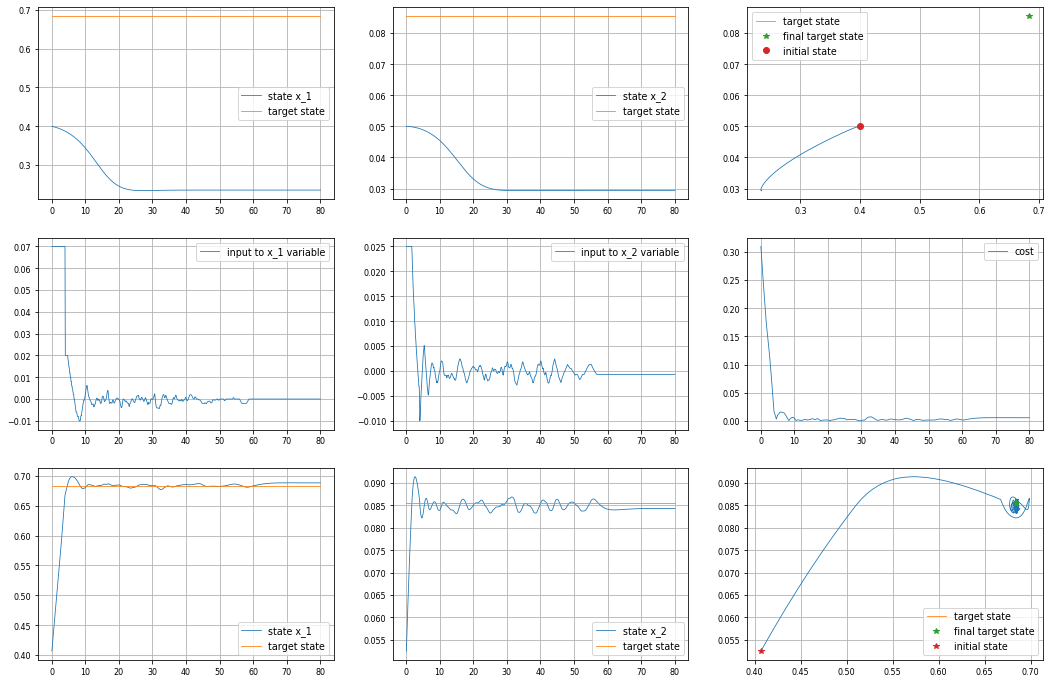

In [363]:
plot_control(target_state, best, f_cost(state, target_state))

### Limit cycle: Force into unstable fixed point

Now, we investigate control in the regime where one finds a limit cycle. This is the case if there is only one fixed point that is located between the minimum and the maximum of the $\dot{x}_1$-nullcline. We change the parameter $\epsilon = 1$ and the external input $x_1 = 0.5$. With these parameters, the fixed point is at $(\frac{1}{3}, \frac{1}{3})$.

The size and frequency of the oscillation depends on the input current $I_{ext}$. The closer to the turning point the fixed point is, the higher the frequency. The higher the input current, the smaller is the limit cycle in the phase plane.

In [364]:
# define model parameters and external input such that we find limit cycle
# in the model above, no external input to x_2 is included

epsilon = 1.0
fhn.params['epsilon'] = epsilon

extr_nullcline = [(-8. + np.sqrt(10.))/-18., (-8. - np.sqrt(10.))/-18.]
I_minmax = np.zeros((2))
for i in range(len(extr_nullcline)):
    I_minmax[i] = 3*extr_nullcline[i]**3 - 4.*extr_nullcline[i]**2 + (1.5 + fhn.params['epsilon'])*extr_nullcline[i]
    
print('Min and max input current for limit cycle: ', I_minmax)

# between 0.465 and 0.712 numerically
external_input = [0.5, 0.0]

fhn.params['x_ext'] = np.array([external_input[0]])
fhn.params['y_ext'] = np.array([external_input[1]])


Min and max input current for limit cycle:  [0.441 0.728]


Fixed point:  [0.333 0.333]


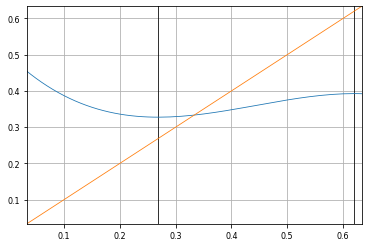

In [336]:
low_lim = -2.
up_lim = 2.
x = np.arange(low_lim,up_lim,0.01)

ic_limitcycle = 0.0

# fixed points for default parameter choice
fixed_point_x = fsolve(fp_func, ic_limitcycle)
fixed_point = [fixed_point_x[0], x1_nullcline(fixed_point_x)[0]]

print('Fixed point: ', np.around(fixed_point, 3) )


plt.plot(x,x1_nullcline(x))
plt.plot(x,x2_nullcline(x))
plt.vlines(extr_nullcline, fixed_point[1]-1.3,fixed_point[1]+1.3)
plt.xlim(fixed_point_x-0.3, fixed_point_x+0.3)
plt.ylim(fixed_point[1]-0.3, fixed_point[1]+0.3)
plt.show()

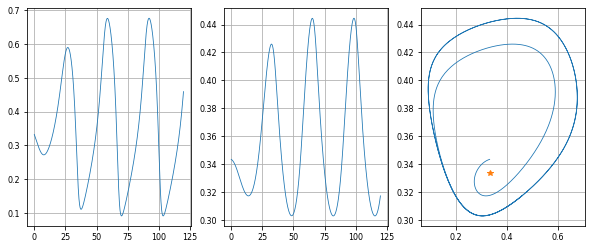

In [365]:
# starting close to the three fixed points, we see that two of them are stable
initial_state = [fixed_point[0], fixed_point[1]+0.01]

#set duration of simulation
duration = 120 # in ms

fhn.params['xs_init']= np.array([[initial_state[0]]])
fhn.params['ys_init']= np.array([[initial_state[1]]])
fhn.params['epsilon'] = epsilon
fhn.params['duration'] = duration
fhn.run()

t = np.arange(0, fhn.params['duration'], fhn.params['dt'])

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].plot(t, fhn.x[0,:])
ax[1].plot(t, fhn.y[0,:])
ax[2].plot(fhn.x[0,:], fhn.y[0,:])
ax[2].plot(fixed_point[0], fixed_point[1], '*')
plt.show()


In [341]:
# Calculate the period of the oscillation

x_oscillation = np.zeros((2,2))
x_oscillation[0,1] = np.max(fhn.x[0,:])
x_oscillation[0,0] = np.where(fhn.x[0,:] == x_oscillation[0,1])[0]
x_oscillation[1,1] = np.max(fhn.x[0,:int(x_oscillation[0,0])-15])
x_oscillation[1,0] = np.where(fhn.x[0,:] == x_oscillation[1,1])[0]
if ( abs(x_oscillation[1,0] - x_oscillation[0,0]) < 17):
    x_oscillation[1,1] = np.max(fhn.x[0,int(x_oscillation[0,0])+15:-1])
    x_oscillation[1,0] = np.where(fhn.x[0,:] == x_oscillation[1,1])[0]

period = abs(x_oscillation[1,0] - x_oscillation[0,0])*fhn.params['dt']
print("Oscillation period: ", period)

Oscillation period:  33.4


In [366]:
# force the system into the instable fixed point

tolerance = 1e-2
inst_tolerance = 1e-6
step_size = 0.01

target_state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
start_fixed_point = 1 # lower (0), unstable (1) or upper (2)
target_fixed_point = 2 # lower (0), unstable (1) or upper (2)
fhn.params['xs_init']= np.array([[fixed_point[0]+0.01]])
fhn.params['ys_init']= np.array([[fixed_point[0]+0.01]])
target_state[:,0,:] = fixed_point[0]
target_state[:,1,:] = fixed_point[1]

control0 = fhn.getZeroControl()
max_iteration = 6

opt, best = opt_control(control0, f_cost, step_size, target_state, tolerance, inst_tolerance, max_iteration)

#print('optimal solution: ', opt)
#print('best solution: ', best)
state = np.zeros((fhn.params['N'], len(fhn.output_vars), int(duration/fhn.params['dt'])))
fhn.run(control = best)

state[:,0,:] = fhn.x[:,:]
state[:,1,:] = fhn.y[:,:]

RUN  0 , total integrated cost:  22.045215243099136
RUN  1 , total integrated cost:  22.44154748587791
RUN  2 , total integrated cost:  22.35375503332459
RUN  3 , total integrated cost:  21.681671189979884
RUN  4 , total integrated cost:  20.94319180900155
RUN  5 , total integrated cost:  20.49601324846826


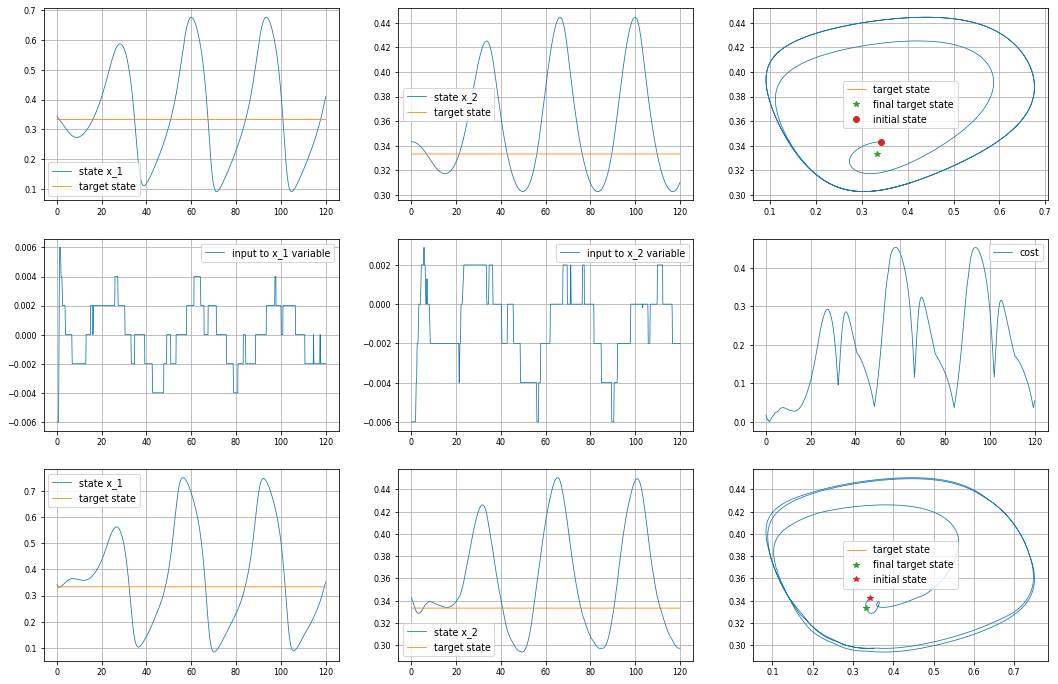

In [370]:
plot_control(target_state, best, f_cost(state, target_state))

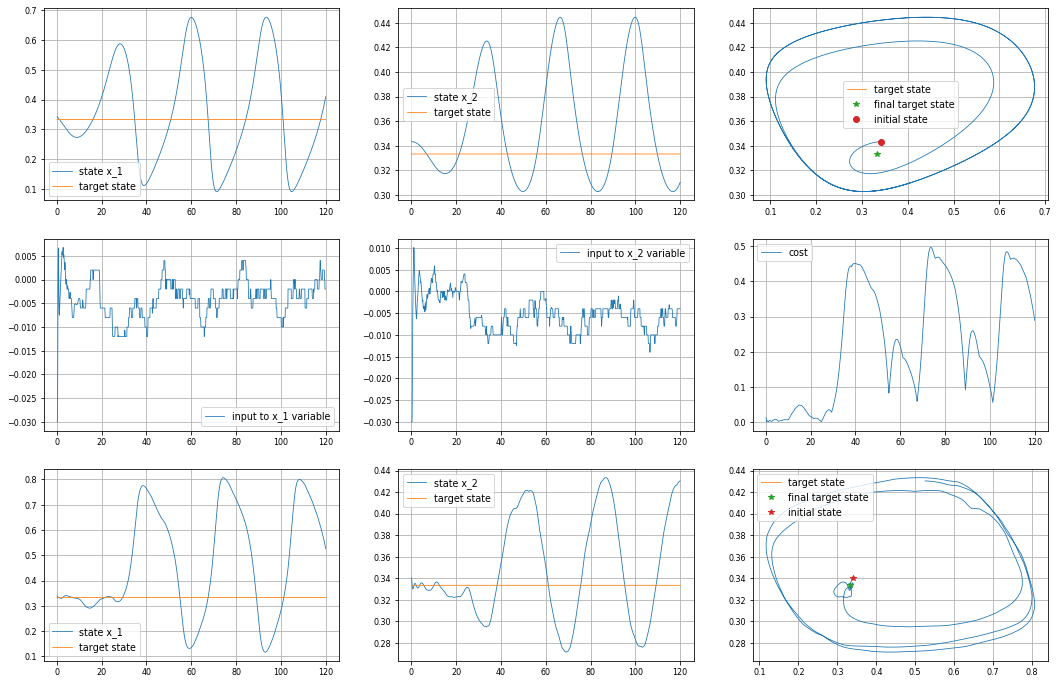

In [348]:
plot_control(target_state, best, f_cost(state, target_state))

Next steps:
- improve optimization algorithm (stepsize, conjugate gradient descent, approximation based on less granular time steps)
- other cases: oscillation at different frequency/ amplitude
- cost function that penalizes energy
- two- or three-node network (with cost function penalizing sparsity)

Starting from a linearization around $\mathbf{c}^*$, this translates to

$$ \begin{align}
\int_0^T [\nabla_c f(\mathbf{x}(\mathbf{c}^*), \mathbf{c}^*) + D_c^T (\mathbf{x}(\mathbf{c}^*))\cdot \nabla_x f(\mathbf{x}(\mathbf{c}^*), \mathbf{c}^*)] \circ (\mathbf{c} - \mathbf{c}^*) dt = 0,
\end{align}$$

with $\circ$ denoting the elementwise multiplication (Schur product). The term in squared brackets needs to vanish.

We therefore need to compute
- the gradient of the cost function with respect to the control, $\nabla_c f(\mathbf{x}(\mathbf{c}), \mathbf{c})$,
- the Jacobian Matrix of the state vector with respect to the control, $D_c^T (\mathbf{x}(\mathbf{c}^*))$,
- the gradient of the cost function with respect to the state, $\nabla_x f(\mathbf{x}(\mathbf{c}^*), \mathbf{c}^*)$.

For a start, we do all computations using as many useful python packages as possible. Later, it might be required to implement our own (faster) algorithms.

Obtaining the Jacobian $D_c$ is not possible in a straightforward way. Applying the method of Lagrange multipliers, one can find an expression for $D_c^T (\mathbf{x}(\mathbf{c}^*) \nabla_x f(\mathbf{x}(\mathbf{c}^*), \mathbf{c}^*)$, that can be substituted in the above equation. We therefore define

$$ \begin{align}
\mathcal{L}(\mathbf{x}(\mathbf{c}), \mathbf{c})) = F(\mathbf{x}) + \lambda \cdot(\dot{\mathbf{x}} - \mathbf{h}(\mathbf{x}) - \mathbf{c}(t)).
\end{align}$$

We find

$$ \begin{align}
\nabla_\mathbf{c} f(\mathbf{x}(\mathbf{c}^*), \mathbf{c}^*) + \mathbf{\lambda} = 0.
\end{align}$$